# Processing Gain: Extracting a Signal from the Noise

Before we dive into the noise, we need to understand the fundamental trade-off in Digital Signal Processing: **The Bin Width ($\Delta f$)**.

When we run an FFT, we divide our detectable spectrum into "buckets" or bins. The size of these buckets is dictated by two things:
1. **Sampling Frequency ($F_s$):** This dictates the maximum frequency we can see (Nyquist = $F_s/2$). A higher $F_s$ means a wider total view.
2. **FFT Length ($N$):** This is the number of samples we process at once.

The formula for the width of a single frequency bin is:
$$\Delta f = \frac{F_s}{N} \text{ (Hz per bin)}$$

**The Trade-off:**
* If you want to detect faster signals, you must increase $F_s$. But if $N$ stays the same, your bins get wider, blurring closely spaced frequencies together and letting more noise into each bin.
* To get sharper resolution and block out noise, you must increase $N$ (using narrower bins). However, a larger $N$ requires more hardware memory and introduces **Latency** (you have to wait longer to collect the samples).

### The Concept of Processing Gain
Think of the FFT bins as a row of buckets catching rain. 
* **The Signal** is a concentrated stream of water falling into **one specific bucket**.
* **The Noise** is a chaotic mist falling **everywhere**.

When we increase $N$, our buckets get narrower. Each bucket now catches less "mist" (noise), but the "stream" (David) still lands entirely in his specific bucket. This makes the signal-to-noise ratio in that bin skyrocket.

## 1. The Raw Input
We will generate 2048 samples of our noisy environment. We'll look at the signal before and after the **Hann Window** is applied. 
Notice that in the time domain, David is mathematically invisible.

Signal David Amplitude: 0.00398
Signal Noise Amplitude: 0.01


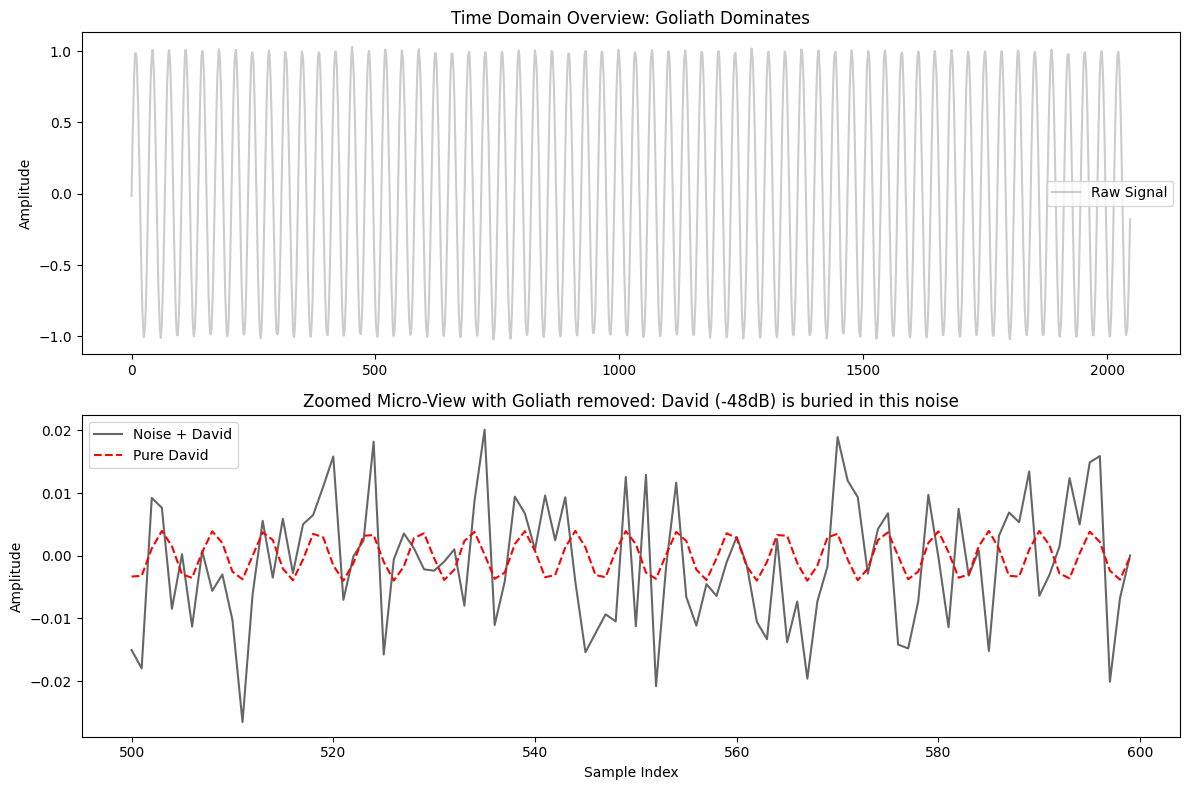

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim, analyze_fft_performance

N_max = 2048
t_max = np.arange(N_max)
noise_amp = 0.01

# --- THE CALIBRATION CONSTANTS ---
HANN_GAIN = 0.5  # Hann window reduces signal by 6dB
FS = 1024        # Sample Rate

# Define signals by FREQUENCY (Hz), not bins, so they scale with N
goliath_freq_hz = 30 
david_freq_hz = 200
david_amp = 10**(-48/20)

# Noise at 0.01 (Buries David in Time Domain)
noise = noise_amp * np.random.randn(N_max)
goliath = 1.0 * np.sin(2 * np.pi * goliath_freq_hz * t_max / FS)
david = david_amp * np.sin(2 * np.pi * david_freq_hz * t_max / FS)
raw_signal = goliath + david + noise

print(f"Signal David Amplitude: {david_amp:.5f}")
print(f"Signal Noise Amplitude: {noise_amp}")
#windowed_signal = raw_signal * np.hanning(N_max)

# Refined Time Domain Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Overview
ax1.plot(t_max, raw_signal, color='gray', alpha=0.4, label="Raw Signal")
ax1.set_title("Time Domain Overview: Goliath Dominates")
ax1.set_ylabel("Amplitude")
ax1.legend()

dn = david+noise
# Zoomed-in "Micro-View"
zoom_start, zoom_end = 500, 600 # Just 100 samples
ax2.plot(t_max[zoom_start:zoom_end], dn[zoom_start:zoom_end], 
         color='black', alpha=0.6, label="Noise + David")
ax2.plot(t_max[zoom_start:zoom_end], david[zoom_start:zoom_end], 
         'r--', label="Pure David")

ax2.set_title(f"Zoomed Micro-View with Goliath removed: David (-48dB) is buried in this noise")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Comparing FFT Sizes
Now, we run the hardware simulation on the same signal at three different lengths. 
* **512 Samples:** A wide view, high noise floor.
* **1024 Samples:** Better resolution.
* **2048 Samples:** Our most powerful "lens."

Watch how the "grass" (noise floor) sinks lower with every step, while David's peak stays at the same relative height.

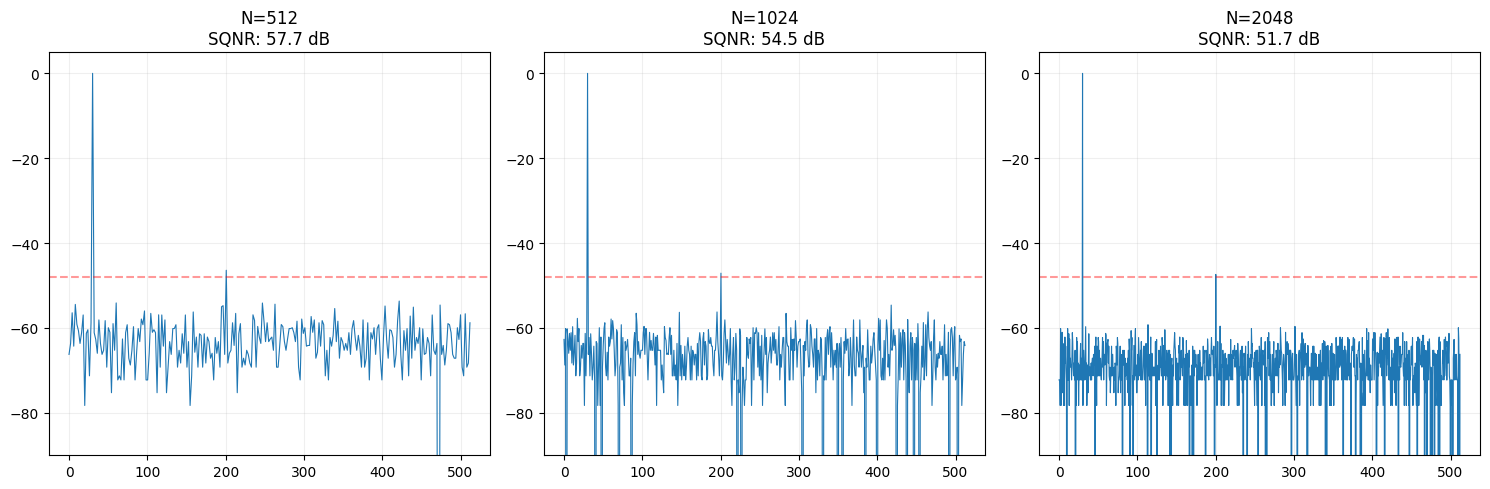

In [119]:
lengths = [512, 1024, 2048]
plt.figure(figsize=(15, 5))

for i, N in enumerate(lengths):
    sig_slice = raw_signal[:N] #* np.hanning(N)
    fft_hw, exp, _ = run_sim(sig_slice, invert=False)
    
    # 1. SCALE BY EXPONENT (Undo the Hardware Scaling)
    fft_corrected = fft_hw * (2.0**exp)
    
    # 2. SCALE BY WINDOW GAIN & N (Normalize to 0 dB)
    # Magnitude = (abs / (N/2)) / HANN_GAIN
    mag = np.abs(fft_corrected[:N//2]) / (N * 0.5)# * HANN_GAIN)
    mag_db = 20 * np.log10(mag + 1e-12)
    
    # 3. Use your helper for the real Noise Floor Stats
    # We compare against a pure numpy version of the same slice
    stats = analyze_fft_performance(raw_signal[:N], fft_hw, exp)
    
    plt.subplot(1, 3, i+1)
    plt.plot(np.linspace(0, FS/2, N//2), mag_db, linewidth=0.8)
    plt.axhline(-48, color='r', linestyle='--', alpha=0.4)
    plt.title(f"N={N}\nSQNR: {stats['sqnr_db']:.1f} dB")
    plt.ylim([-90, 5])
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Key Observations:
1. **The Peak Height:** David's peak stays near the **-48 dB** line in all three graphs. This is because he is a "Coherent" signal; all his energy stays in his specific frequency bins.
2. **The Sinking Grass:** Notice the "average" level of the noise floor. In the **512** plot, the noise floor is quite close to David. In the **2048** plot, the noise floor has dropped significantly. 
3. **The Result:** David goes from being a "maybe" to a "certainty." By simply looking at more samples (oversampling), our Hardware FFT has physically filtered out the noise without any complex digital filters!

## 3. The Ultimate Extraction: Separating the Signals
Finally, we use the "Frequency Domain Filter" technique to completely decouple our two signals. 

We will take our noisy **2048-point HW FFT**, and create two separate, blank frequency spaces. We will copy Goliath's peak into one, and David's peak into the other. By performing an IFFT on both, we will pull them completely out of the noise storm and separate them into their own distinct time-domain channels.

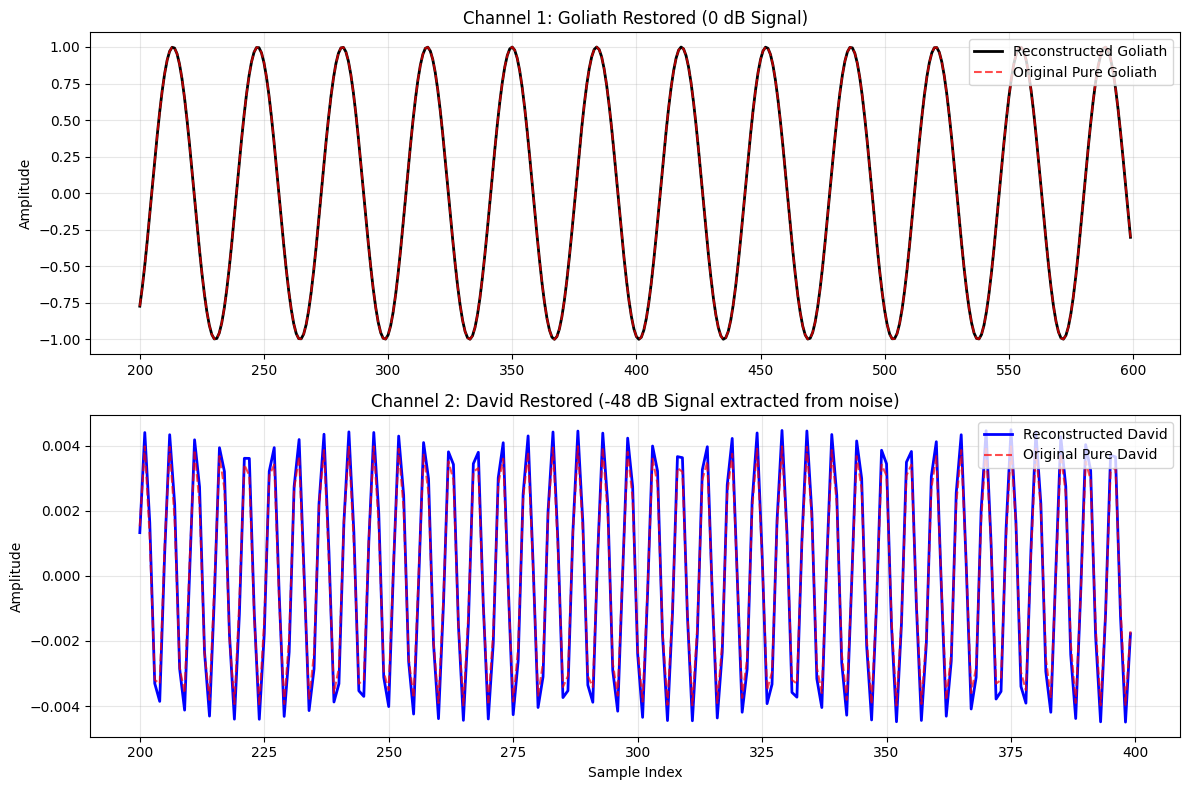

In [122]:
# Using the 2048 result for best quality
N = 2048
sig_slice = raw_signal[:N] #* np.hanning(N)
fft_hw, exp, _ = run_sim(sig_slice, invert=False)
fft_aligned = fft_hw * (2.0**exp)

# Calculate exact bin locations
bin_g = int(goliath_freq_hz * N / FS)
bin_d = int(david_freq_hz * N / FS)

# Create TWO separate clean masks
fft_goliath_only = np.zeros_like(fft_aligned, dtype=complex)
fft_david_only = np.zeros_like(fft_aligned, dtype=complex)

# Helper function to isolate a peak into a specific target array
def copy_peak(source_fft, target_fft, center_bin, width=1):
    # Copy Positive Frequency Peak
    target_fft[center_bin-width : center_bin+width+1] = source_fft[center_bin-width : center_bin+width+1]
    # Copy Negative Frequency Mirror
    mirror = len(source_fft) - center_bin
    target_fft[mirror-width : mirror+width+1] = source_fft[mirror-width : mirror+width+1]

# Extract them into their respective arrays
copy_peak(fft_aligned, fft_goliath_only, bin_g)
copy_peak(fft_aligned, fft_david_only, bin_d)

# Perform Inverse FFTs
restored_goliath = np.fft.ifft(fft_goliath_only)
restored_david = np.fft.ifft(fft_david_only)

# "De-window" the center of the signal to restore original amplitudes
de_window = (np.hanning(N) + 1e-5)
time_goliath = restored_goliath.real #/ de_window
time_david = restored_david.real #/ de_window

# --- Plot the Separated Signals ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Goliath
ax1.plot(t_max[200:600], time_goliath[200:600], 'k-', linewidth=2, label="Reconstructed Goliath")
ax1.plot(t_max[200:600], goliath[200:600], 'r--', alpha=0.7, label="Original Pure Goliath")
ax1.set_title("Channel 1: Goliath Restored (0 dB Signal)")
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Plot 2: David
ax2.plot(t_max[200:400], time_david[200:400], 'b-', linewidth=2, label="Reconstructed David")
ax2.plot(t_max[200:400], david[200:400], 'r--', alpha=0.7, label="Original Pure David")
ax2.set_title("Channel 2: David Restored (-48 dB Signal extracted from noise)")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()